In [1]:
# Cell 1: Imports and setup
import os
import torch
from scipy.io import loadmat

# Set the dataset path (adjust if needed)
dataset_path = "./dropbox/Chair/"

# List the first few files in each folder
folders = ["boxes", "labels", "models", "obbs", "ops", "part mesh indices", "syms"]
for f in folders:
    folder_path = os.path.join(dataset_path, f)
    files = sorted(os.listdir(folder_path))
    print(f"{f}: {len(files)} files, first 5: {files[:5]}")

boxes: 6201 files, first 5: ['1.mat', '10.mat', '100.mat', '1000.mat', '1001.mat']
labels: 6201 files, first 5: ['1.mat', '10.mat', '100.mat', '1000.mat', '1001.mat']
models: 6201 files, first 5: ['1095.obj', '1127.obj', '1277.obj', '1282.obj', '1284.obj']
obbs: 6201 files, first 5: ['1095.obb', '1127.obb', '1277.obb', '1282.obb', '1284.obb']
ops: 6201 files, first 5: ['1.mat', '10.mat', '100.mat', '1000.mat', '1001.mat']
part mesh indices: 6201 files, first 5: ['1.mat', '10.mat', '100.mat', '1000.mat', '1001.mat']
syms: 6201 files, first 5: ['1.mat', '10.mat', '100.mat', '1000.mat', '1001.mat']


In [2]:
shape_id = 1  # you can change this to inspect other shapes

# Load .mat files
boxes = loadmat(os.path.join(dataset_path, "boxes", f"{shape_id}.mat"))['box']
labels = loadmat(os.path.join(dataset_path, "labels", f"{shape_id}.mat"))['label']
ops = loadmat(os.path.join(dataset_path, "ops", f"{shape_id}.mat"))['op']
syms = loadmat(os.path.join(dataset_path, "syms", f"{shape_id}.mat"))['sym']
part_indices = loadmat(os.path.join(dataset_path, "part mesh indices", f"{shape_id}.mat"))['cell_boxs_correspond_objSerialNumber']

# Print shapes and a preview
print("Boxes shape:", boxes.shape)
print("Labels shape:", labels.shape)
print("Ops shape:", ops.shape)
print("Syms shape:", syms.shape)
print("Part mesh indices type:", type(part_indices))
print("Part mesh indices preview:", part_indices[0])

Boxes shape: (12, 3)
Labels shape: (1, 3)
Ops shape: (1, 5)
Syms shape: (8, 1)
Part mesh indices type: <class 'numpy.ndarray'>
Part mesh indices preview: [array([[5, 6, 7, 8]], dtype=uint8) array([[ 9, 10]], dtype=uint8)
 array([[1, 2, 3, 4]], dtype=uint8)]


In [3]:
# Flatten part indices into a simple list of arrays
flattened_part_indices = [arr for arr in part_indices[0]]
print("Number of parts:", len(flattened_part_indices))
print("First part indices:", flattened_part_indices[0])

Number of parts: 3
First part indices: [[5 6 7 8]]


In [4]:
import sys
import os

# Add the src directory to sys.path
sys.path.append(os.path.abspath("."))

In [5]:
# Cell 3: Visualize the boxes of the shape (corrected)
from draw3dobb import showGenshape
import torch

# Flatten boxes: from (12,3) → (12*1? check), but draw3dobb expects 12 values per box (center + 3 dirs)
# We'll compute center and dirs from the 12 corner points if needed, or just flatten for now
boxes_for_vis = [torch.tensor(box).float().view(-1).unsqueeze(0) for box in boxes]

# Display the boxes
showGenshape(boxes_for_vis)

ValueError: incompatible dimensions for cross product
(dimension must be 2 or 3)

<Figure size 640x480 with 0 Axes>

In [ ]:
# visualize_obbs.ipynb

# %%
# Imports
import os
import torch
from scipy.io import loadmat
from draw3dobb import draw, showGenshapes
from matplotlib import pyplot as plt

# %%
# Set dataset path
DATA_DIR = "./dropbox/Chair/"  # Change to 'Bag' if needed
BOX_DIR = os.path.join(DATA_DIR, "boxes")

# List the available .mat files in boxes
box_files = sorted([f for f in os.listdir(BOX_DIR) if f.endswith(".mat")])
print(f"Found {len(box_files)} bounding box files. Showing first 5:")
box_files[:5]

# %%
# Function to load boxes from a .mat file
def load_boxes(file_path):
    data = loadmat(file_path)
    # Assuming the variable storing boxes is called 'boxes' in the .mat file
    # Each row corresponds to [center(3), lengths(3), dir1(3), dir2(3)]
    boxes = data['box']  # shape: [num_boxes, 12]
    return boxes

# %%
# Example: visualize a single shape
shape_idx = 1  # choose a shape index (1.mat, 2.mat, etc.)
boxes = load_boxes(os.path.join(BOX_DIR, f"{shape_idx}.mat"))

# Convert to a list for showGenshapes
boxes_list = [boxes[i, :].tolist() for i in range(boxes.shape[0])]

# Show the bounding boxes
showGenshapes([boxes_list])  # note: showGenshapes expects a list of shapes

# %%
# Optional: visualize all shapes in boxes folder (slower)
for file_name in box_files:
    boxes = load_boxes(os.path.join(BOX_DIR, file_name))
    boxes_list = [boxes[i, :].tolist() for i in range(boxes.shape[0])]
    showGenshapes([boxes_list])

Found 6201 bounding box files. Showing first 5:


ValueError: incompatible dimensions for cross product
(dimension must be 2 or 3)

<Figure size 640x480 with 0 Axes>

Found 6201 bounding box files. Showing first 5:


/var/folders/zb/9bmh3s9s3q5_mlv24by4t5x00000gn/T/ipykernel_50865/1899707949.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(box_files))


ValueError: incompatible dimensions for cross product
(dimension must be 2 or 3)

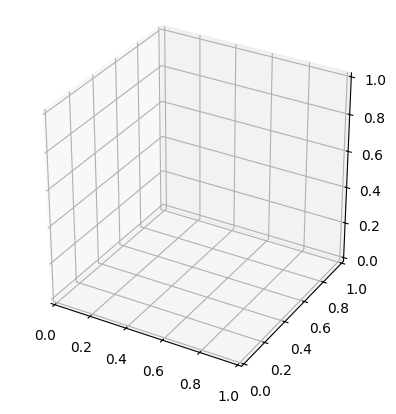

In [ ]:
# visualize_all_obbs.ipynb

# %%
# Imports
import os
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from matplotlib import cm
from draw3dobb import draw
from mpl_toolkits.mplot3d import Axes3D

# %%
# Set dataset path
DATA_DIR = "./dropbox/Chair"  # Change to "./dropbox/Bag" for Bag dataset
BOX_DIR = os.path.join(DATA_DIR, "boxes")

# List all .mat files
box_files = sorted([f for f in os.listdir(BOX_DIR) if f.endswith(".mat")])
print(f"Found {len(box_files)} bounding box files. Showing first 5:")
box_files[:5]

# %%
# Function to load boxes safely
def load_boxes(file_path):
    data = loadmat(file_path)
    # Automatically pick the variable that contains the box array
    # Usually the key is 'box'
    for k in data.keys():
        if not k.startswith("__"):
            boxes = data[k]
            break
    return boxes

# %%
# Fixed draw function that flattens input vectors
def draw_fixed(ax, p, color='b'):
    p = np.array(p).flatten()  # flatten in case it's (12,1) or (12,)
    
    center = p[0:3]
    l = p[3:6]
    dir_1 = p[6:9]
    dir_2 = p[9:12]
    
    # Compute third direction
    dir_3 = np.cross(dir_1, dir_2)
    dir_3 = dir_3 / np.linalg.norm(dir_3)
    
    # Compute 8 corner points
    cornerpoints = np.zeros([8,3])
    dirs = [dir_1, dir_2, dir_3]
    signs = [[-1,-1,-1], [-1,-1,1], [-1,1,-1], [-1,1,1],
             [1,-1,-1], [1,-1,1], [1,1,-1], [1,1,1]]
    for i in range(8):
        for j in range(3):
            cornerpoints[i] += signs[i][j] * dirs[j] * l[j]/2
        cornerpoints[i] += center
    
    # Draw edges
    lines = [[0,1],[0,2],[0,4],[1,3],[1,5],[2,3],[2,6],[3,7],[4,5],[4,6],[5,7],[6,7]]
    for line in lines:
        ax.plot([cornerpoints[line[0],0], cornerpoints[line[1],0]],
                [cornerpoints[line[0],1], cornerpoints[line[1],1]],
                [cornerpoints[line[0],2], cornerpoints[line[1],2]],
                color=color)

# %%
# Function to visualize a single shape
def visualize_shape(file_path, color='b'):
    boxes = load_boxes(file_path)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.set_box_aspect([1,1,1])
    
    for i in range(boxes.shape[0]):
        draw_fixed(ax, boxes[i,:], color=color)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title(os.path.basename(file_path))
    plt.show()

# %%
# Visualize all shapes with different colors
colors = cm.get_cmap('tab20', len(box_files))

for idx, file_name in enumerate(box_files):
    file_path = os.path.join(BOX_DIR, file_name)
    color = colors(idx)
    visualize_shape(file_path, color=color)